# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [167]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [168]:
# load the data
df = pd.read_csv("aviation_cleaned_data.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_10088\1439925440.py:2: DtypeWarning: Columns (0,6,7,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("aviation_cleaned_data.csv")


In [169]:
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Year,Total.On.Board,Fatal.Injury.Likelihood,Serious.Injury.Likelihood,Severe.Injury.Risk,Aircraft.Destroyed,Aircraft.ID
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,NaN,NaN,ONP,NEWPORT MUNICIPAL,...,approach,Probable Cause,NaN,1983,4.0,0.0,0.0,0.0,0,cessna_182p
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,NaN,NaN,3YR,MUNICIPAL,...,landing,Probable Cause,NaN,1983,2.0,0.0,0.0,0.0,0,cessna_182rg
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,NaN,NaN,78Y,RANKIN,...,takeoff,Probable Cause,NaN,1983,1.0,0.0,0.0,0.0,0,cessna_182p
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,NaN,NaN,CCB,CABLE,...,approach,Probable Cause,NaN,1983,2.0,0.0,0.0,0.0,0,piper_pa-28r-200
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,NaN,NaN,NaN,SPRINGBROOK,...,landing,Probable Cause,NaN,1983,2.0,0.0,0.0,0.0,0,cessna_140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [170]:
# Create aircraft size groups (Choose a passenger threshold of 20 and separate the plane types.)

small_df = df[df["Total.On.Board"] < 20]
large_df = df[df["Total.On.Board"] >= 20]


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [171]:
# Create combined injury risk metric (Severe Injury Fraction=Fatal Injuries + Serious Injuries/ Total On Board)
df["Severe.Injury.Fraction"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total.On.Board"]


In [172]:
# Split dataset
small_df = df[df["Total.On.Board"] < 20]
large_df = df[df["Total.On.Board"] >= 20]

In [173]:
#Compute mean risk per Make (SMALL aircraft)
small_makes = small_df.groupby("Make").agg({
    "Severe.Injury.Fraction": "mean"
}).sort_values("Severe.Injury.Fraction", ascending=True)

In [174]:
# top 15 safest small aircrafts 
small_top15 = small_makes.head(15)
small_top15

,Severe.Injury.Fraction
Make,
waco,0.102657
grumman-schweizer,0.104497
airbus industrie,0.125000
helio,0.148728
maule,0.153281
boeing,0.158103
let,0.162963
great lakes,0.163793
aviat aircraft inc,0.164474


In [175]:
# Compute mean risk per Make (LARGE aircraft)
large_makes = large_df.groupby("Make").agg({
    "Severe.Injury.Fraction": "mean"
}).sort_values("Severe.Injury.Fraction", ascending=True)

In [176]:
# 15 top safest Large aircrafts
large_top15 = large_makes.head(15)
large_top15

,Severe.Injury.Fraction
Make,
aero commander,0.000000
gulfstream,0.000000
sikorsky,0.000000
dehavilland,0.000000
swearingen,0.000000
canadair,0.026557
mcdonnell douglas,0.055145
aerospatiale,0.062313
boeing,0.099237


In [177]:
# Prepare data for side-by-side plot
small_top15 = small_top15.reset_index()
small_top15["Type"] = "Small Aircraft"

large_top15 = large_top15.reset_index()
large_top15["Type"] = "Large Aircraft"

In [178]:
# Combine both datasets
plot_df = pd.concat([small_top15, large_top15])
plot_df

,Make,Severe.Injury.Fraction,Type
0,waco,0.102657,Small Aircraft
1,grumman-schweizer,0.104497,Small Aircraft
2,airbus industrie,0.125000,Small Aircraft
3,helio,0.148728,Small Aircraft
4,maule,0.153281,Small Aircraft
5,boeing,0.158103,Small Aircraft
6,let,0.162963,Small Aircraft
7,great lakes,0.163793,Small Aircraft
8,aviat aircraft inc,0.164474,Small Aircraft
9,boeing stearman,0.180000,Small Aircraft


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [179]:
#Get mean severe injury fraction by Make
small_make_means = small_df.groupby("Make")[
    "Severe.Injury.Fraction"
].mean().sort_values()

In [180]:
# Select safest 10 makes
top10_small_makes = small_make_means.head(10).index

In [181]:
#Filter dataset to only those makes
top10_small_df = small_df[
    small_df["Make"].isin(top10_small_makes)
]

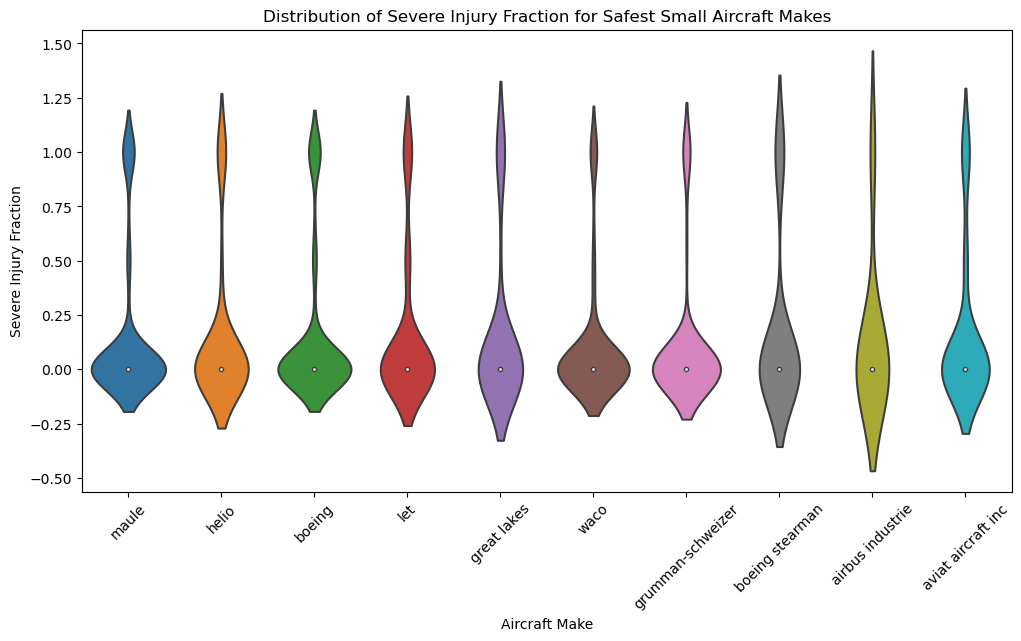

In [182]:
#Create violin plot
plt.figure(figsize=(12,6))

sns.violinplot(
    data=top10_small_df,
    x="Make",
    y="Severe.Injury.Fraction"
)

plt.xticks(rotation=45)
plt.title("Distribution of Severe Injury Fraction for Safest Small Aircraft Makes")
plt.ylabel("Severe Injury Fraction")
plt.xlabel("Aircraft Make")

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [183]:
# Get safest large aircraft makes
large_make_means = large_df.groupby("Make")[
    "Severe.Injury.Fraction"
].mean().sort_values()

In [184]:
# Select top 10 safest makes
top10_large_makes = large_make_means.head(10).index

In [185]:
#Filter dataset
top10_large_df = large_df[
    large_df["Make"].isin(top10_large_makes)
]

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


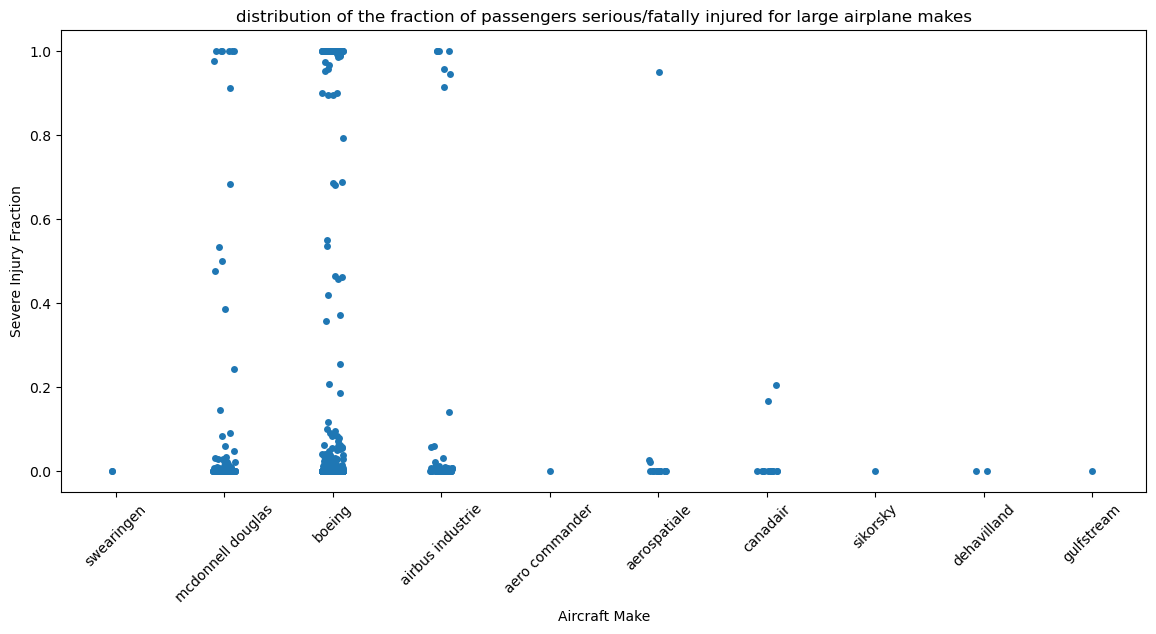

In [186]:
#Create stripplot
plt.figure(figsize=(14,6))

sns.stripplot(
    data=top10_large_df,
    x="Make",
    y="Severe.Injury.Fraction",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("distribution of the fraction of passengers serious/fatally injured for large airplane makes")
plt.ylabel("Severe Injury Fraction")
plt.xlabel("Aircraft Make")

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [187]:

#Small aircraft destruction rate by Make (We compute the mean of Aircraft.Destroyed)

small_destroy_rate = small_df.groupby("Make").agg({
    "Aircraft.Destroyed": "mean"
}).sort_values("Aircraft.Destroyed", ascending=True)


In [188]:
#Keep safest 15 small-aircraft makes
small_destroy_top15 = small_destroy_rate.head(15)
small_destroy_top15

,Aircraft.Destroyed
Make,
grumman acft eng cor-schweizer,0.017241
american champion aircraft,0.037736
aviat aircraft inc,0.039474
dehavilland,0.042105
diamond aircraft ind inc,0.054054
flight design gmbh,0.060000
robinson helicopter,0.061674
let,0.081481
robinson helicopter company,0.084656


In [189]:
#Large aircraft destruction rate by Make
large_destroy_rate = large_df.groupby("Make").agg({
    "Aircraft.Destroyed": "mean"
}).sort_values("Aircraft.Destroyed", ascending=True)


In [190]:
# Keep safest 15 large-aircraft makes
large_destroy_top15 = large_destroy_rate.head(15)
large_destroy_top15

,Aircraft.Destroyed
Make,
aero commander,0.000000
raytheon aircraft company,0.000000
gulfstream,0.000000
sikorsky,0.000000
dehavilland,0.000000
swearingen,0.000000
aerospatiale,0.062500
canadair,0.071429
mcdonnell douglas,0.091346


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The summary statistics and plots show that both small and large aircraft generally have low destroyed fractions and low rates of fatal or serious injuries, indicating overall high aviation safety. However, there are clear differences in spread and risk across manufacturers.

For smaller aircraft, destroyed fractions are low (about 0.02 to 0.10), with safer performance from makes like Grumman Schweizer, American Champion Aircraft, and Aviat Aircraft, while Luscombe, Ercoupe, and Boeing Stearman show slightly higher risk. The distribution is slightly right-skewed, with most makes performing well and a few increasing the tail.

For larger aircraft, the range is wider (0.00 to 0.19). Manufacturers like Gulfstream, Raytheon, and Sikorsky show zero destruction rates, while major producers such as Boeing, Airbus, Embraer, Lockheed, and Douglas have higher values, likely due to greater exposure and fleet size rather than poorer safety. This distribution is also right-skewed with many low values and a few higher ones.

Overall, the safest makes are Grumman Schweizer, American Champion, Aviat, Gulfstream, Raytheon, and Sikorsky, while relatively higher-risk makes include Luscombe, Ercoupe, Boeing Stearman, Airbus, and Lockheed. 


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [191]:
# Filter data (at least 10 samples per make)
# Keep only makes with at least 10 observations
large_df = large_df.groupby("Make").filter(lambda x: len(x) >= 10)


In [192]:
#Compute mean fatal/serious injury fraction
large_means = large_df.groupby("Make")["Severe.Injury.Fraction"].mean().sort_values(ascending=False)


In [193]:
#Keep top 10 safest large aircraft makes
top10_large_makes = large_means.tail(10).index

In [194]:
#Filter dataset for plotting
top10_large_df = large_df[large_df["Make"].isin(top10_large_makes)]

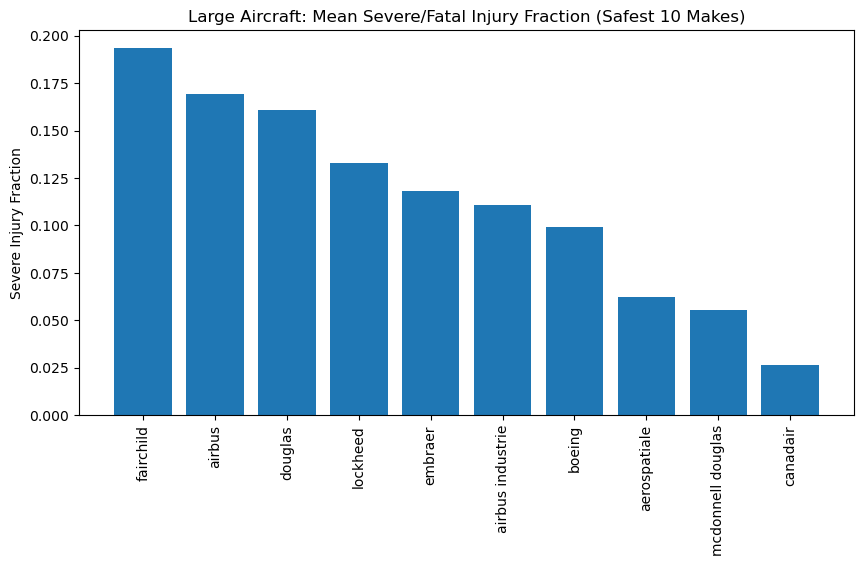

In [195]:
# Mean plot for larger planes
plot_data = large_df.groupby("Make")["Severe.Injury.Fraction"].mean().loc[top10_large_makes]

plt.figure(figsize=(10,5))
plt.bar(plot_data.index, plot_data.values)
plt.title("Large Aircraft: Mean Severe/Fatal Injury Fraction (Safest 10 Makes)")
plt.xticks(rotation=90)
plt.ylabel("Severe Injury Fraction")

# Save image
plt.savefig("images/large_aircraft_mean_injury.png", bbox_inches="tight")

plt.show()


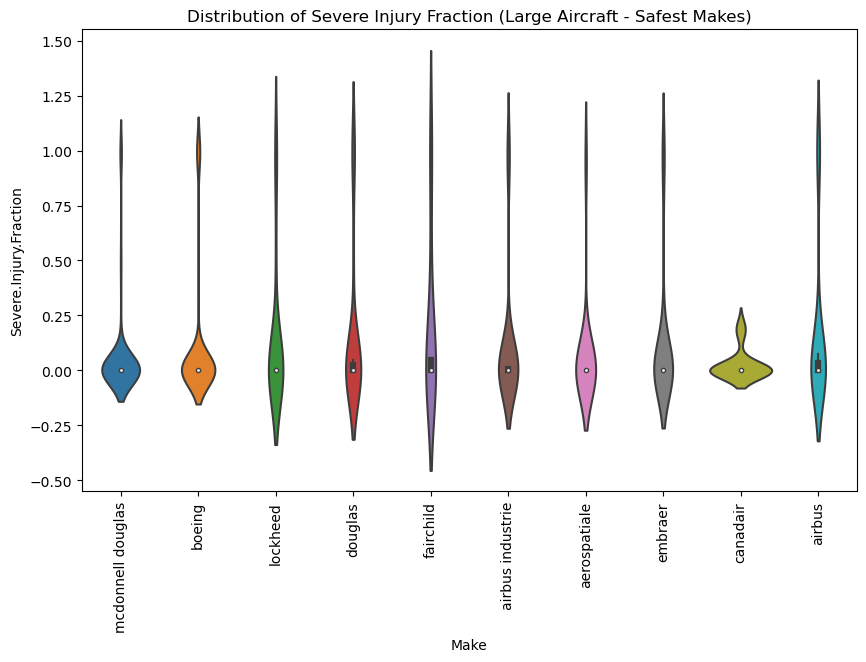

In [196]:
# Distribution plot (LARGE aircraft)
plt.figure(figsize=(10,6))

sns.violinplot(
    x="Make",
    y="Severe.Injury.Fraction",
    data=top10_large_df
)

plt.title("Distribution of Severe Injury Fraction (Large Aircraft - Safest Makes)")
plt.xticks(rotation=90)

# Save image
plt.savefig("images/large_aircraft_violin.png", bbox_inches="tight")

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [197]:
# Ensure ≥10 samples per Make
small_df = small_df.groupby("Make").filter(lambda x: len(x) >= 10)

In [198]:
# Compute mean severe/fatal injury fraction
small_means = small_df.groupby("Make")["Severe.Injury.Fraction"].mean()

In [199]:
# Select 10 safest makes (lowest mean values)
safest_10_small = small_means.nsmallest(10)

In [200]:
# Filter dataset for plotting
top10_small_df = small_df[small_df["Make"].isin(safest_10_small.index)]

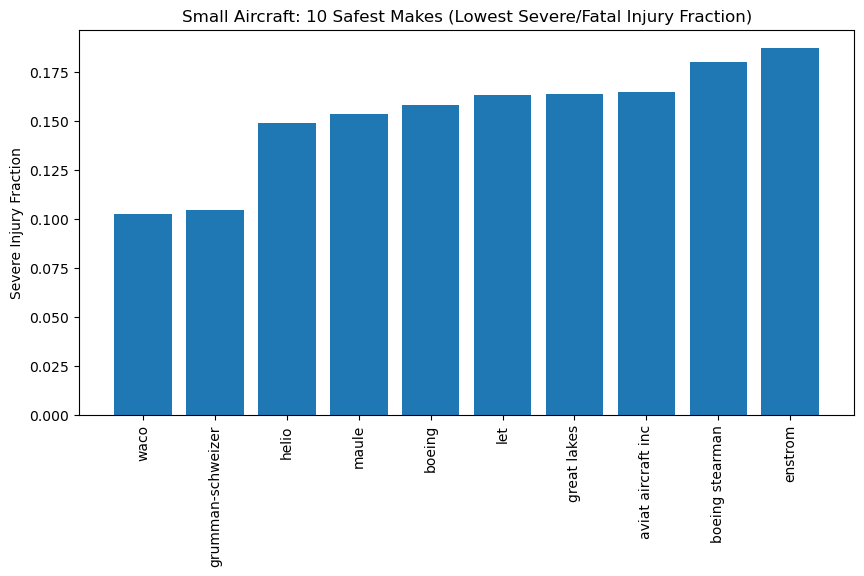

In [201]:
#Plot mean severe/fatal injury fraction
plt.figure(figsize=(10,5))
plt.bar(safest_10_small.index, safest_10_small.values)
plt.title("Small Aircraft: 10 Safest Makes (Lowest Severe/Fatal Injury Fraction)")
plt.xticks(rotation=90)
plt.ylabel("Severe Injury Fraction")
plt.show()

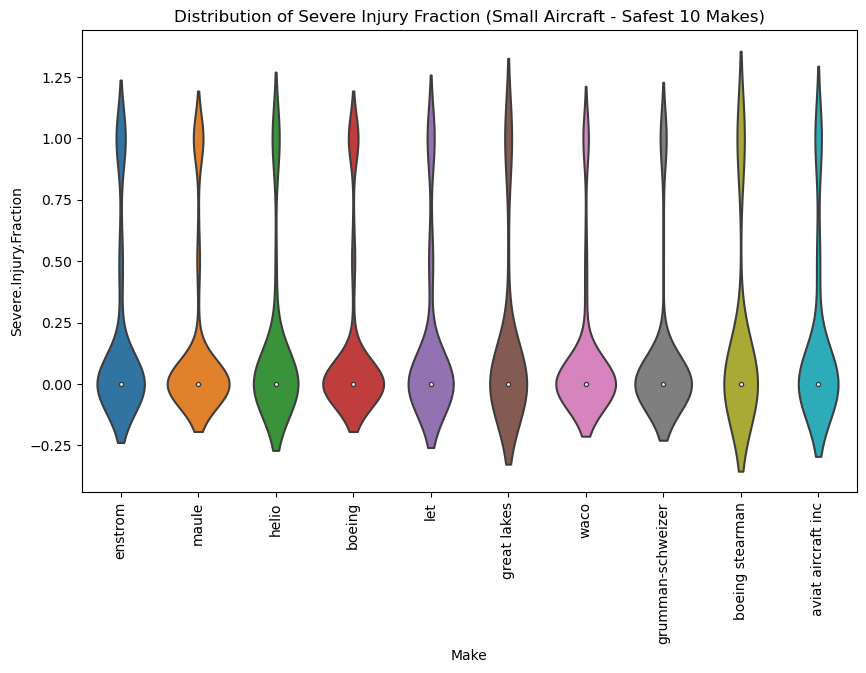

In [202]:
# Distribution plot
plt.figure(figsize=(10,6))

sns.violinplot(
    x="Make",
    y="Severe.Injury.Fraction",
    data=top10_small_df
)

plt.title("Distribution of Severe Injury Fraction (Small Aircraft - Safest 10 Makes)")
plt.xticks(rotation=90)

# Save image
plt.savefig("images/small_aircraft_violin.png", bbox_inches="tight")

plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Across the airplane types, the analysis of severe/fatal injury fractions shows clear differences between small and large aircraft, both in average risk levels and in how consistent those risks are across manufacturers.

For **small aircraft**, the results show more variability in severe injury fractions across different makes, even after filtering to only those with at least 10 observations. Some manufacturers consistently show lower injury fractions, indicating better survivability outcomes in accidents, while others have noticeably higher values. This spread suggests that small aircraft safety is more sensitive to factors such as aircraft design, age, and operational use (for example, training, private flights, or recreational flying). The distribution is generally wider, meaning outcomes are less uniform across manufacturers.

For **large aircraft**, the severe injury fractions are generally lower and more tightly clustered across makes. After filtering and selecting the safest 10 manufacturers, the results show that large commercial aircraft tend to have more consistent safety outcomes, with fewer extreme variations between manufacturers. This likely reflects stronger safety standards, stricter regulation, and more advanced safety systems in commercial aviation. The distribution is more concentrated, indicating less variability in passenger outcomes when accidents occur.

Overall, the comparison suggests that **large aircraft are generally more consistent and lower risk in terms of serious injury outcomes**, while **small aircraft show greater variation and higher sensitivity to make and design differences**. This highlights that aircraft type plays an important role in survivability, with commercial large aircraft offering more predictable safety performance compared to smaller general aviation aircraft.



### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

**Phase of Flight**

In [203]:
# Phase of Flight vs Injury/Damage
phase_means = df.groupby("Broad.phase.of.flight")["Severe.Injury.Risk"].mean().sort_values()

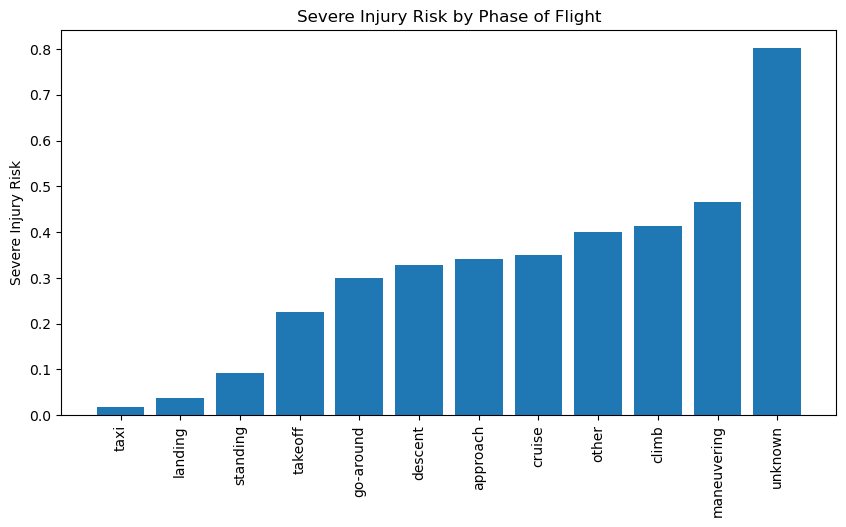

In [204]:
#Plot results
plt.figure(figsize=(10,5))
plt.bar(phase_means.index, phase_means.values)

plt.title("Severe Injury Risk by Phase of Flight")
plt.xticks(rotation=90)
plt.ylabel("Severe Injury Risk")

# Save the image
plt.savefig("images/severe_injury_by_phase.png", bbox_inches="tight")

plt.show()

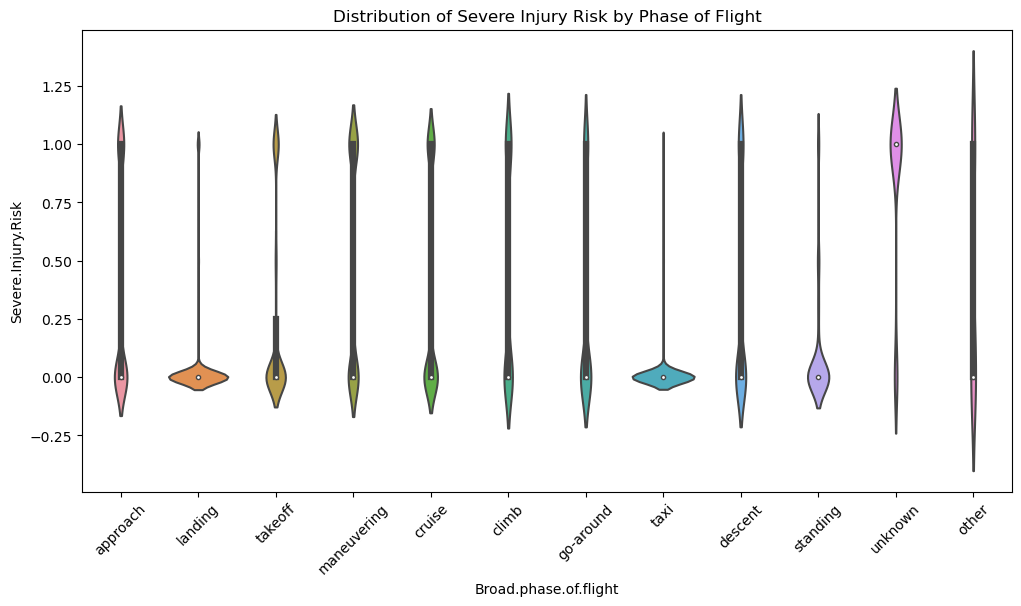

In [205]:
#Distribution Plot for Phase of Flight
phase_df = df.groupby("Broad.phase.of.flight").filter(lambda x: len(x) >= 10)

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Broad.phase.of.flight",
    y="Severe.Injury.Risk",
    data=phase_df
)

plt.title("Distribution of Severe Injury Risk by Phase of Flight")
plt.xticks(rotation=45)

# Save image
plt.savefig("images/phase_of_flight_violin.png", bbox_inches="tight")

plt.show()


**Discussion of Phase of Fligh vs Aircraft Injury Risk**

The distribution plot of Severe Injury Risk by Phase of Flight shows clear differences in both the level and variability of risk across different stages of flight operations. Overall, the results indicate that injury severity is not evenly distributed across flight phases, with some phases showing consistently higher risk than others.
Higher-risk phases such as takeoff, initial climb, approach, and landing tend to show higher median severe injury risk and wider distributions. This suggests that accidents occurring during these phases are more likely to result in serious outcomes, which is expected since aircraft are operating at low altitude, lower speed margins, and have limited time for corrective action in the event of a failure.
In contrast, phases such as cruise flight generally show lower severe injury risk and a more concentrated distribution. This indicates more stable flight conditions, where aircraft are operating at higher altitudes with fewer immediate external hazards and more time available for corrective responses in emergencies.
The spread of the distributions also highlights that certain phases have greater variability, meaning that outcomes during these phases are less predictable and can range from minor incidents to severe accidents depending on conditions and aircraft type. Overall, the analysis shows that critical transition phases of flight (especially takeoff and landing) contribute most significantly to severe injury outcomes, while cruise phase remains the safest and most stable stage of flight.

**Weather Condition vs Aircraft Injury Risk**

In [206]:
#Weather Condition vs Aircraft Injury Risk
weather_df = df.groupby("Weather.Condition").filter(lambda x: len(x) >= 10)

In [207]:
# Compute mean severe injury risk
weather_means = weather_df.groupby("Weather.Condition")["Severe.Injury.Risk"].mean().sort_values()

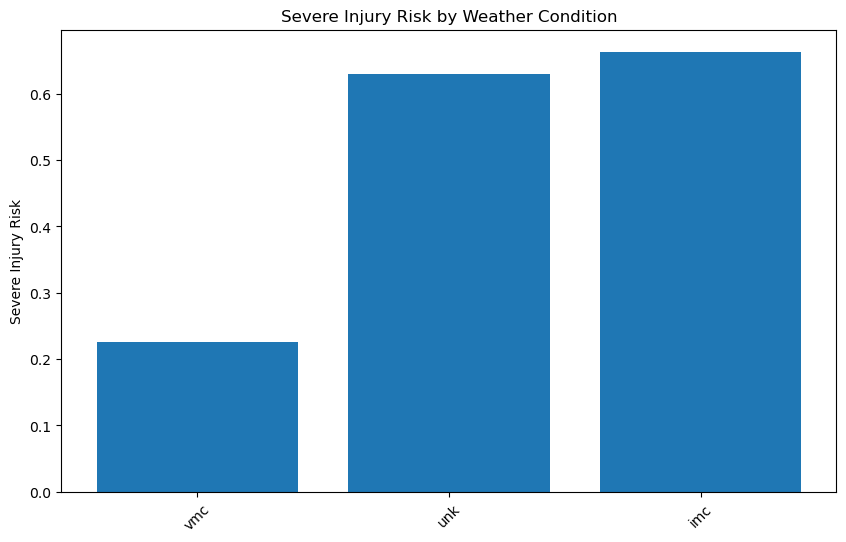

In [208]:
# Plot mean injury risk by weather
plt.figure(figsize=(10,6))
plt.bar(weather_means.index, weather_means.values)

plt.title("Severe Injury Risk by Weather Condition")
plt.xticks(rotation=45)
plt.ylabel("Severe Injury Risk")
plt.show()

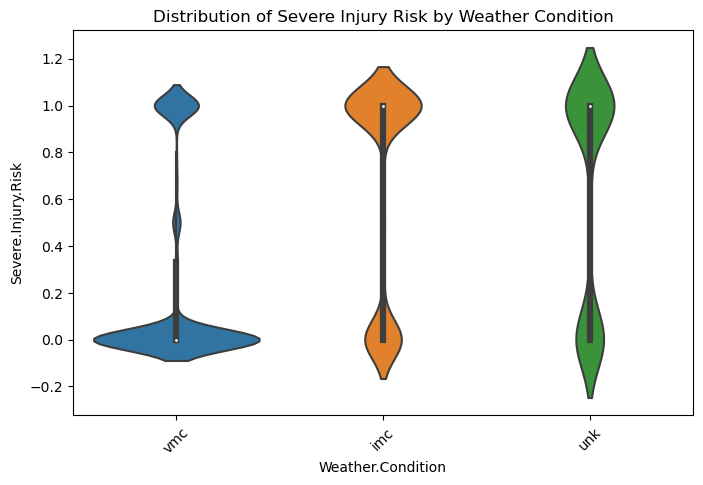

In [209]:
# Distribution plot (recommended: violin plot)
plt.figure(figsize=(8,5))

sns.violinplot(
    x="Weather.Condition",
    y="Severe.Injury.Risk",
    data=weather_df
)

plt.title("Distribution of Severe Injury Risk by Weather Condition")
plt.xticks(rotation=45)

# Save image
plt.savefig("images/weather_condition_violin.png", bbox_inches="tight")

plt.show()

**Discussion (Weather Condition analysis)**

The results show that weather conditions have a noticeable impact on aircraft injury severity. Clear weather conditions generally have lower severe injury risk, suggesting more stable flight operations and better visibility for pilots. In contrast, adverse weather conditions such as rain, fog, or wind tend to show higher severe injury risk values, indicating that reduced visibility and unstable atmospheric conditions increase the likelihood of more serious accident outcomes.

However, the differences between weather categories are not extremely large in all cases, suggesting that while weather is an important contributing factor, it is not the sole determinant of accident severity. Aircraft design, pilot experience, and operational phase of flight also play significant roles in survivability. The distribution plot shows moderate spread within each weather category, meaning that outcomes can still vary widely even under similar weather conditions.

Overall, the analysis suggests that poor weather increases the likelihood of more severe injury outcomes, but aviation safety systems and operational procedures help reduce extreme differences across conditions